Dataset: (307511, 91)
Variables usadas: 67

Distribución TARGET:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64

Tipos de variables:
Numéricas continuas: 52
Numéricas binarias: 7
Categóricas binarias: 1
Categóricas nominales: 7

scale_pos_weight: 11.39

Métricas en test
Threshold:          0.50
ROC-AUC:            0.7708
PR-AUC:             0.2640
Accuracy:           0.7031
Balanced Accuracy:  0.7025
Precision:          0.1719
Recall:             0.7017
F1:                 0.2762
F2:                 0.4341

Classification report:
              precision    recall  f1-score   support

           0     0.9641    0.7032    0.8132     56538
           1     0.1719    0.7017    0.2762      4965

    accuracy                         0.7031     61503
   macro avg     0.5680    0.7025    0.5447     61503
weighted avg     0.9001    0.7031    0.7699     61503



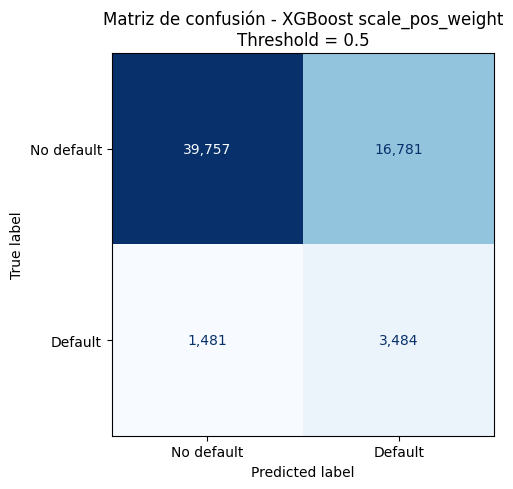

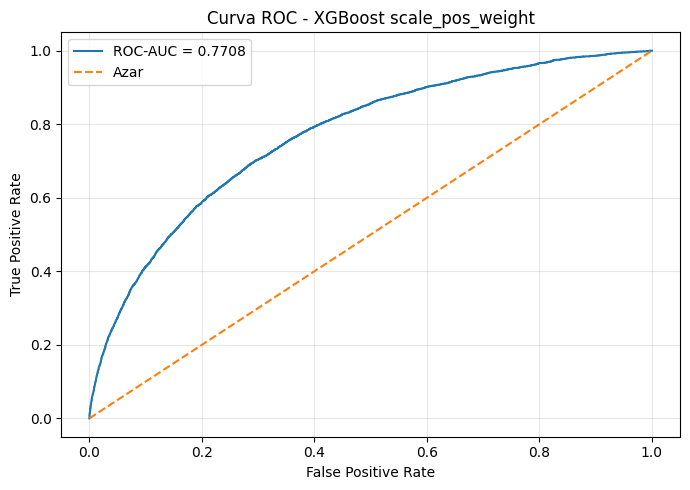

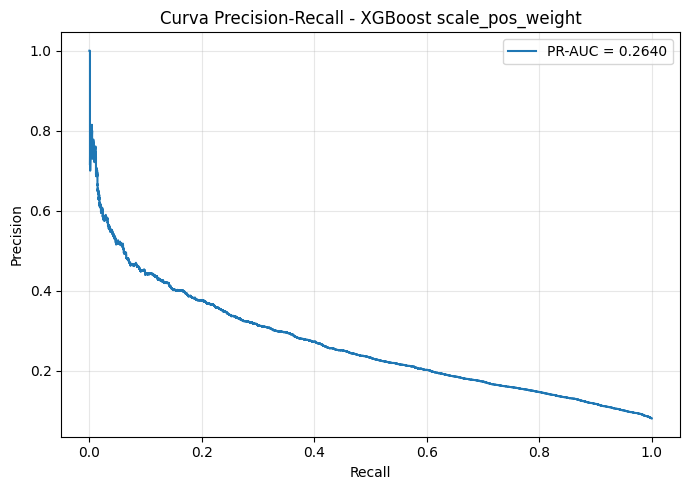

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    balanced_accuracy_score
)

from xgboost import XGBClassifier


# ============================================================
# 1. Configuración
# ============================================================

DATA_PATH = "data/trusted/clean_df.parquet"   # ajusta la ruta si es necesario
TARGET = "TARGET"
ID_COL = "SK_ID_CURR"
THRESHOLD = 0.50
RANDOM_STATE = 42

OUTPUT_DIR = Path("model_outputs/xgb_scale_pos_weight_curves")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Columnas adicionales eliminadas por criterio de negocio.
# Si tu dataset final ya no las tiene, no pasa nada: el código las ignora.
DROP_COLS = [
    "bureau_min_days_credit",
    "bureau_avg_days_update",
    "bureau_n_card",
    "bureau_mean_days_overrun",
    "prev_application_mean",
    "prev_annuity_approved_mean",
    "prev_cnt_payment_max",
    "prev_insured_on_approval_count",
    "prev_insured_on_approval_rate",
    "WEEKDAY_APPR_PROCESS_START",
    "FONDKAPREMONT_MODE",
    "NAME_TYPE_SUITE",
    "FLAG_OWN_REALTY",
    "EMERGENCYSTATE_MODE",
    "WALLSMATERIAL_MODE",
    "HOUSETYPE_MODE",
    "LANDAREA_AVG",
    "NONLIVINGAREA_AVG",
    "BASEMENTAREA_AVG",
    "CNT_FAM_MEMBERS",
    "INCOME_PER_PERSON",
    "OBS_60_CNT_SOCIAL_CIRCLE"
]


# ============================================================
# 2. Cargar dataset
# ============================================================

df = pd.read_parquet(DATA_PATH)

df = df.dropna(subset=[TARGET]).copy()
df[TARGET] = df[TARGET].astype(int)

drop_cols_existing = [c for c in DROP_COLS if c in df.columns]

features = [
    c for c in df.columns
    if c not in [TARGET, ID_COL] and c not in drop_cols_existing
]

X = df[features].copy()
y = df[TARGET].copy()

print(f"Dataset: {df.shape}")
print(f"Variables usadas: {len(features)}")
print("\nDistribución TARGET:")
print(y.value_counts(normalize=True).round(4))


# ============================================================
# 3. Separar train/test
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)


# ============================================================
# 4. Separar tipos de variables
# ============================================================

cat_cols = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()

num_cols = [c for c in X_train.columns if c not in cat_cols and c not in bool_cols]

cat_binary_cols = []
cat_nominal_cols = []

for col in cat_cols:
    if X_train[col].dropna().nunique() <= 2:
        cat_binary_cols.append(col)
    else:
        cat_nominal_cols.append(col)

num_binary_cols = []
num_continuous_cols = []

for col in num_cols:
    values = X_train[col].dropna().unique()
    if len(values) == 2 and set(pd.Series(values).astype(float)).issubset({0.0, 1.0}):
        num_binary_cols.append(col)
    else:
        num_continuous_cols.append(col)

num_binary_cols.extend(bool_cols)

print("\nTipos de variables:")
print(f"Numéricas continuas: {len(num_continuous_cols)}")
print(f"Numéricas binarias: {len(num_binary_cols)}")
print(f"Categóricas binarias: {len(cat_binary_cols)}")
print(f"Categóricas nominales: {len(cat_nominal_cols)}")


# ============================================================
# 5. Preprocesamiento
# ============================================================

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num_cont",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler(with_mean=False))
            ]),
            num_continuous_cols
        ),
        (
            "num_bin",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent"))
            ]),
            num_binary_cols
        ),
        (
            "cat_bin",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                ))
            ]),
            cat_binary_cols
        ),
        (
            "cat_nom",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", onehot)
            ]),
            cat_nominal_cols
        )
    ],
    remainder="drop",
    sparse_threshold=0.3
)


# ============================================================
# 6. Modelo XGBoost con scale_pos_weight
# ============================================================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb_model)
])


# ============================================================
# 7. Entrenamiento
# ============================================================

pipeline.fit(X_train, y_train)

y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)


# ============================================================
# 8. Métricas
# ============================================================

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("\nMétricas en test")
print("=" * 50)
print(f"Threshold:          {THRESHOLD:.2f}")
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"PR-AUC:             {pr_auc:.4f}")
print(f"Accuracy:           {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:          {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:             {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1:                 {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F2:                 {fbeta_score(y_test, y_pred, beta=2, zero_division=0):.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))


# ============================================================
# 9. Matriz de confusión
# ============================================================

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No default", "Default"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format=",d", cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión - XGBoost scale_pos_weight\nThreshold = {THRESHOLD}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_xgb_scale_pos_weight.png", dpi=150)
plt.show()


# ============================================================
# 10. Curva ROC
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - XGBoost scale_pos_weight")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_xgb_scale_pos_weight.png", dpi=150)
plt.show()


# ============================================================
# 11. Curva Precision-Recall
# ============================================================

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - XGBoost scale_pos_weight")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pr_curve_xgb_scale_pos_weight.png", dpi=150)
plt.show()

In [2]:
pipeline.fit(X_train, y_train)
y_prob = pipeline.predict_proba(X_test)[:, 1]

/workspaces/Proyecto_Integrador/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


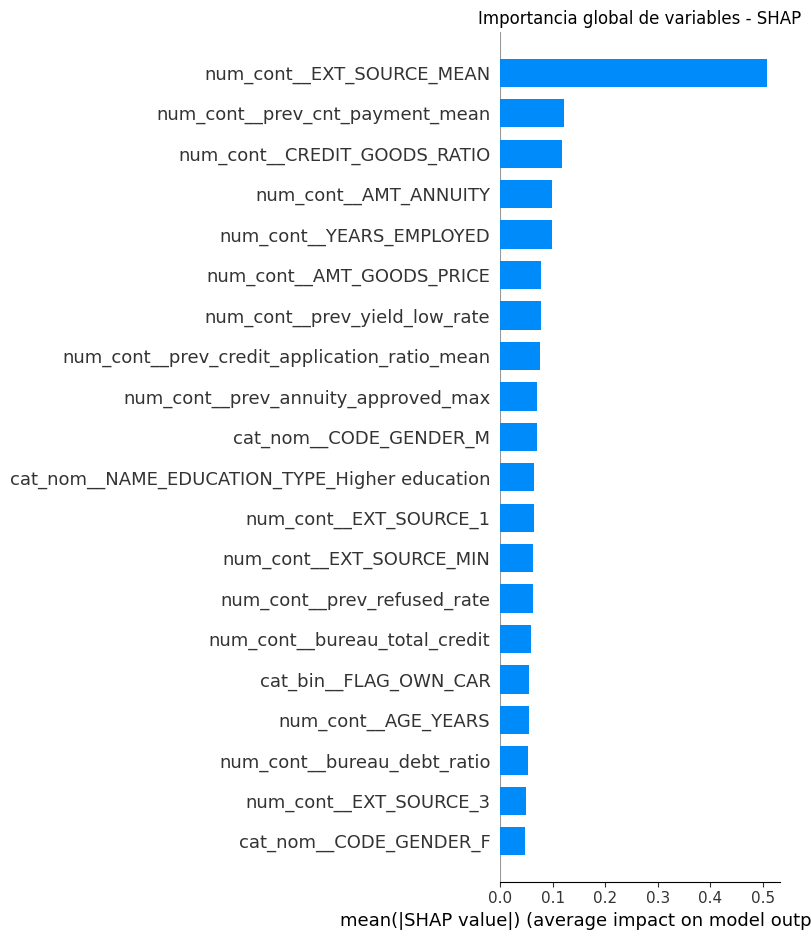

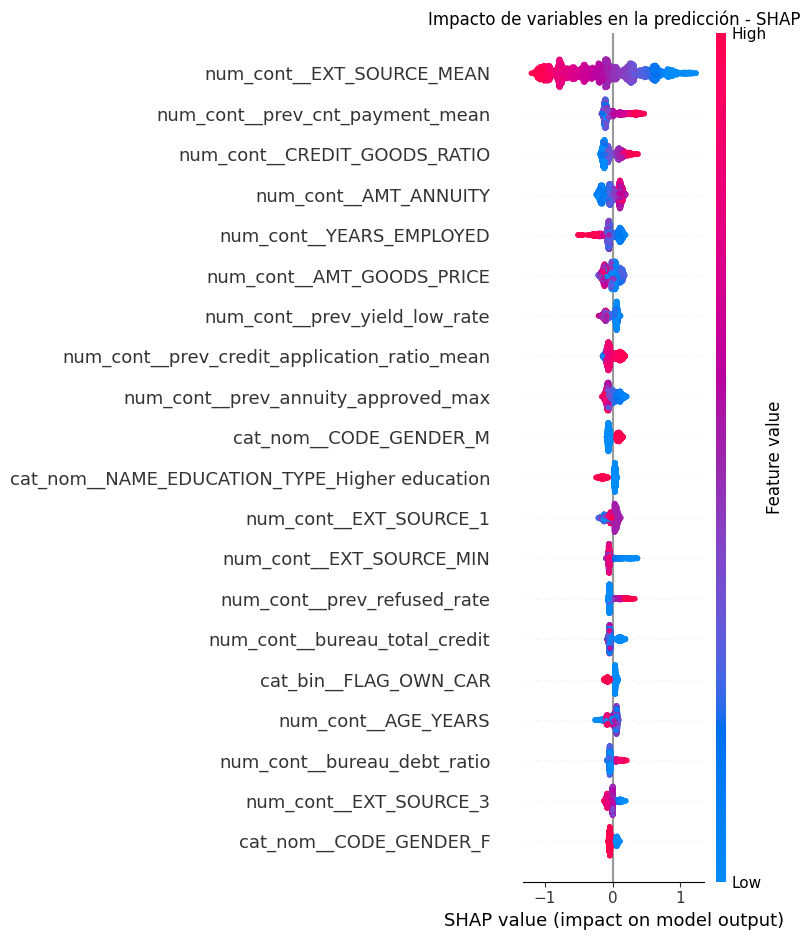

In [3]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extraer preprocesador y modelo del pipeline
preprocessor = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["model"]

# Transformar datos
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Obtener nombres de variables después del One-Hot
feature_names = preprocessor.get_feature_names_out()

# Para no consumir demasiada RAM, usar una muestra
sample_size = 3000
idx = np.random.choice(X_test_proc.shape[0], size=sample_size, replace=False)

X_shap = X_test_proc[idx]

# Si queda sparse y SHAP da error, convertir solo la muestra a dense
if hasattr(X_shap, "toarray"):
    X_shap = X_shap.toarray()

# Crear explicador SHAP para XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# ============================
# Importancia global
# ============================

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("Importancia global de variables - SHAP")
plt.tight_layout()
plt.savefig("shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================
# Impacto y dirección de variables
# ============================

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.title("Impacto de variables en la predicción - SHAP")
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

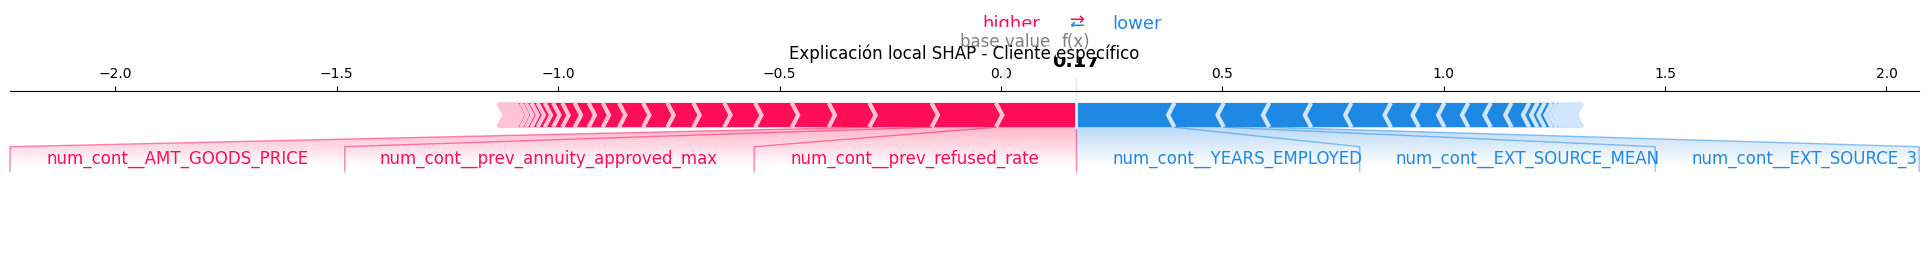

In [4]:
cliente_idx = 0

shap.plots.force(
    explainer.expected_value,
    shap_values[cliente_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)

plt.title("Explicación local SHAP - Cliente específico")
plt.tight_layout()
plt.savefig("shap_cliente_especifico.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Nivel de error permitido
alpha = 0.10  # 90% de cobertura esperada

# Separar train en entrenamiento real y calibración
X_fit, X_calib, y_fit, y_calib = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

# Reentrenar el pipeline solo con X_fit
pipeline_conformal = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb_model)
])

pipeline_conformal.fit(X_fit, y_fit)

# Probabilidades en calibración
calib_proba = pipeline_conformal.predict_proba(X_calib)

# Score de no conformidad:
# 1 - probabilidad asignada a la clase verdadera
calib_scores = 1 - calib_proba[np.arange(len(y_calib)), y_calib.values]

# Cuantil conforme
n = len(calib_scores)
qhat = np.quantile(
    calib_scores,
    np.ceil((n + 1) * (1 - alpha)) / n,
    method="higher"
)

print(f"qhat: {qhat:.4f}")

# Probabilidades en test
test_proba = pipeline_conformal.predict_proba(X_test)

# Construir conjuntos conformes
prediction_sets = []

for probs in test_proba:
    pred_set = []

    for clase in [0, 1]:
        score = 1 - probs[clase]
        if score <= qhat:
            pred_set.append(clase)

    # Evitar conjunto vacío: si no entra ninguna clase,
    # dejar la clase con mayor probabilidad
    if len(pred_set) == 0:
        pred_set = [int(np.argmax(probs))]

    prediction_sets.append(pred_set)

# Evaluar cobertura
contains_true = [
    y_test.iloc[i] in prediction_sets[i]
    for i in range(len(y_test))
]

coverage = np.mean(contains_true)
avg_set_size = np.mean([len(s) for s in prediction_sets])
uncertain_rate = np.mean([len(s) == 2 for s in prediction_sets])

print(f"Cobertura empírica: {coverage:.4f}")
print(f"Tamaño promedio del conjunto: {avg_set_size:.4f}")
print(f"% casos inciertos {{0,1}}: {uncertain_rate:.4f}")

qhat: 0.6850
Cobertura empírica: 0.9052
Tamaño promedio del conjunto: 1.4940
% casos inciertos {0,1}: 0.4940


In [6]:
results_conformal = pd.DataFrame({
    "y_true": y_test.values,
    "prob_default": test_proba[:, 1],
    "pred_threshold_050": (test_proba[:, 1] >= 0.50).astype(int),
    "conformal_set": prediction_sets,
    "is_uncertain": [len(s) == 2 for s in prediction_sets]
})

results_conformal.head()

,y_true,prob_default,pred_threshold_050,conformal_set,is_uncertain
0,0,0.377313,0,"[0, 1]",True
1,0,0.264459,0,[0],False
2,0,0.747227,1,[1],False
3,0,0.434225,0,"[0, 1]",True
4,0,0.478408,0,"[0, 1]",True


In [7]:
def decision_rule(row):
    if row["conformal_set"] == [1]:
        return "Riesgo alto"
    elif row["conformal_set"] == [0]:
        return "Riesgo bajo"
    else:
        return "Revisión manual"

results_conformal["decision_conformal"] = results_conformal.apply(decision_rule, axis=1)

results_conformal["decision_conformal"].value_counts(normalize=True)

decision_conformal
Revisión manual    0.493976
Riesgo bajo        0.387542
Riesgo alto        0.118482
Name: proportion, dtype: float64